In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as mtransforms
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

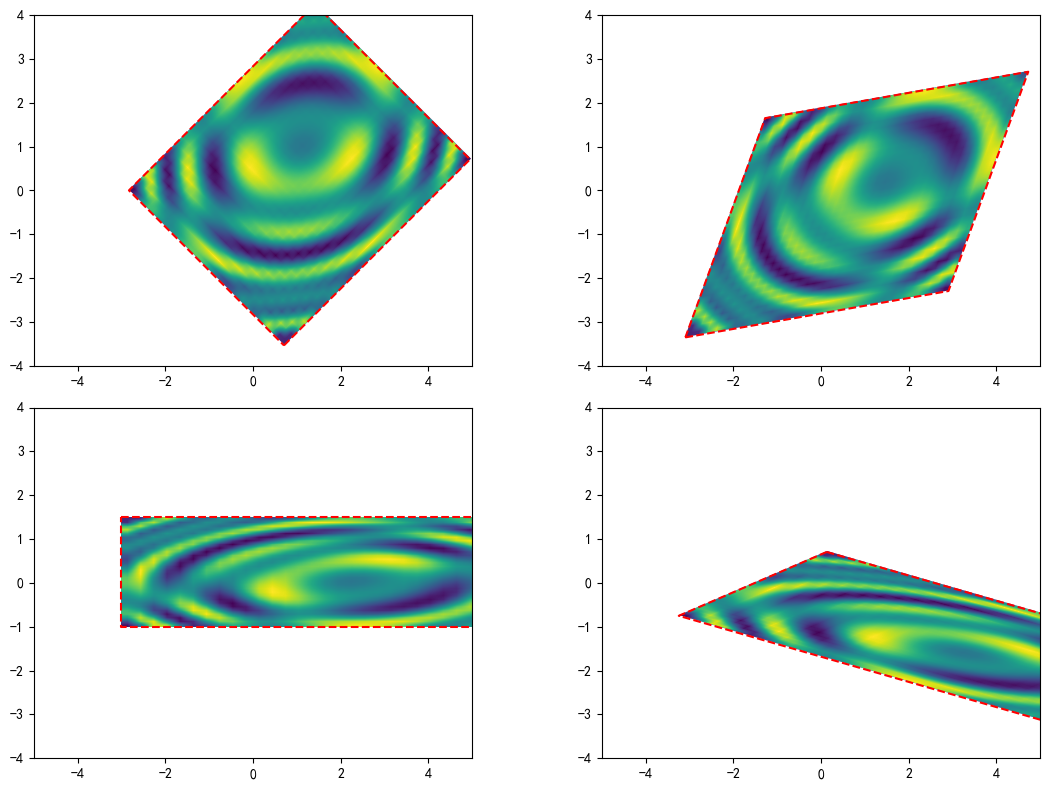

In [7]:

def generate_data():
    """生成图像数据"""
    delta = 0.2
    x = y = np.arange(-3.0, 3.0, delta)
    X, Y = np.meshgrid(x, y)
    Z1 = np.sin(X**2 + Y**2)
    Z2 = np.cos((X - 1)**2 + (Y - 1)**2)
    Z = Z1 - Z2
    return Z

def apply_transform(ax, Z, transform):
    """在给定的轴上应用变换并绘制图像"""
    im = ax.imshow(Z, interpolation='bilinear',
                   origin='lower',
                   extent=[-2, 4, -3, 2], clip_on=True)

    trans_data = transform + ax.transData
    im.set_transform(trans_data)

    # 显示图像的预期范围
    x1, x2, y1, y2 = im.get_extent()
    ax.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], "r--",
            transform=trans_data)
    ax.set_xlim(-5, 5)
    ax.set_ylim(-4, 4)

# 准备数据和图形
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
Z = generate_data()

# 图像旋转
apply_transform(ax1, Z, mtransforms.Affine2D().rotate_deg(45))

# 图像倾斜
apply_transform(ax2, Z, mtransforms.Affine2D().skew_deg(20, 10))

# 缩放和反射
apply_transform(ax3, Z, mtransforms.Affine2D().scale(1.5, -0.5))

# 综合变换：旋转、倾斜、缩放和移动
apply_transform(ax4, Z, mtransforms.Affine2D()
                .rotate_deg(45).skew_deg(20, 10).scale(1.5, -0.5).translate(1, -1))

plt.tight_layout()
plt.show()


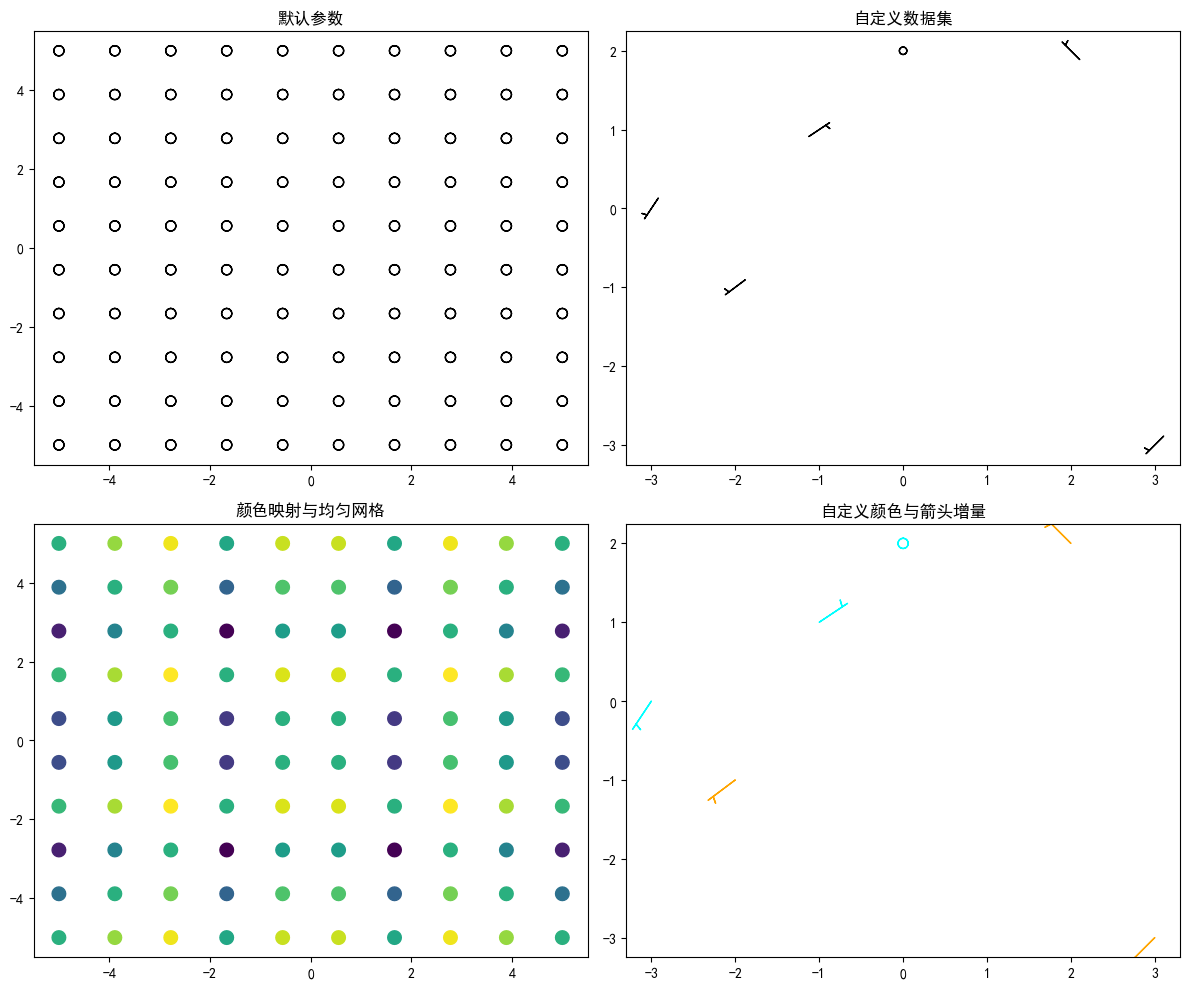

In [9]:
# 生成网格数据
x = np.linspace(-5, 5, 10)
X, Y = np.meshgrid(x, x)
U, V = np.cos(X), np.sin(Y)

# 包含位置和方向信息
data = [(-2, -1, 4, 3),
        (0, 2, -2, -1),
        (3, -3, 5, 5),
        (-1, 1, -3, -2),
        (2, 2, 4, -4),
        (-3, 0, 2, 3)]

data = np.array(data, dtype=[('x', np.float32), ('y', np.float32),
                             ('u', np.float32), ('v', np.float32)])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# 默认参数，均匀网格
axs[0, 0].barbs(X, Y, U, V)
axs[0, 0].set_title('默认参数')

# 使用自定义的数据集，调整向量长度并将旋转点设为中点
axs[0, 1].barbs(
    data['x'], data['y'], data['u'], data['v'], length=6, pivot='middle')
axs[0, 1].set_title('自定义数据集')

# 显示颜色映射与均匀网格，填充空的箭头，不进行舍入，并调整一些大小参数
axs[1, 0].barbs(
    X, Y, U, V, np.sqrt(U ** 2 + V ** 2), fill_empty=True, rounding=False,
    sizes=dict(emptybarb=0.2, spacing=0.15, height=0.25))
axs[1, 0].set_title('颜色映射与均匀网格')

# 修改颜色以及箭头的增量
axs[1, 1].barbs(data['x'], data['y'], data['u'], data['v'], flagcolor='purple',
                 barbcolor=['orange', 'cyan'], flip_barb=True,
                 barb_increments=dict(half=5, full=10, flag=50))
axs[1, 1].set_title('自定义颜色与箭头增量')

plt.tight_layout()
plt.show()


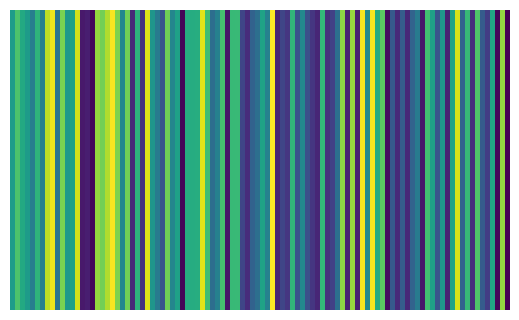

In [13]:
# 生成随机数据
np.random.seed(0)  # 设置随机种子以便结果可重现
data_length = 100  # 数据长度
data = np.random.random(data_length)  # 生成随机数作为数据

# 设置每个条形的像素数和分辨率
pixels_per_bar = 5
dpi = 100

# 创建图形，设置图形的尺寸和分辨率
fig = plt.figure(figsize=(data_length * pixels_per_bar / dpi, 3), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])  # 使坐标轴占据整个图形区域
ax.set_axis_off()  # 关闭坐标轴显示

# 绘制热图
# 这里的数据通过reshape使其成为二维数组，并用灰度色图展示
ax.imshow(data.reshape(1, -1), cmap='viridis', aspect='auto', interpolation='nearest')

# 显示图形
plt.show()


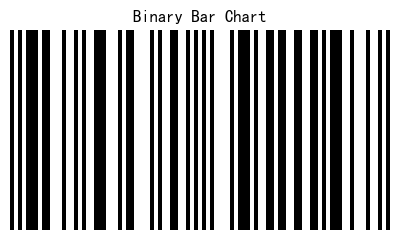

In [15]:
# 数据  
code = np.array([  
    1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,  
    0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,  
    1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,  
    1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1  
])  
  
# 每个条形的像素数  
pixel_per_bar = 4  
# DPI（每英寸点数）  
dpi = 100  
  
# 计算图形尺寸  
# 假设我们想要图形更宽一些，可以调整高度和宽度的比例  
figsize_width = len(code) * pixel_per_bar / dpi  
figsize_height = 2  # 可以根据需要调整这个值  
  
# 创建图形和坐标轴  
fig = plt.figure(figsize=(figsize_width, figsize_height), dpi=dpi)  
ax = fig.add_axes([0, 0, 1, 1])  # 坐标轴占据整个图形  
  
# 关闭坐标轴  
ax.set_axis_off()  
  
# 绘制数据  
# 使用reshape将一维数组转换为二维数组，其中只有一行  
ax.imshow(code.reshape(1, -1), cmap='binary', aspect='auto', interpolation='nearest')  
  
# 添加标题（可选）  
ax.set_title('Binary Bar Chart', fontsize=12)  
  
# 显示图形  
plt.show()

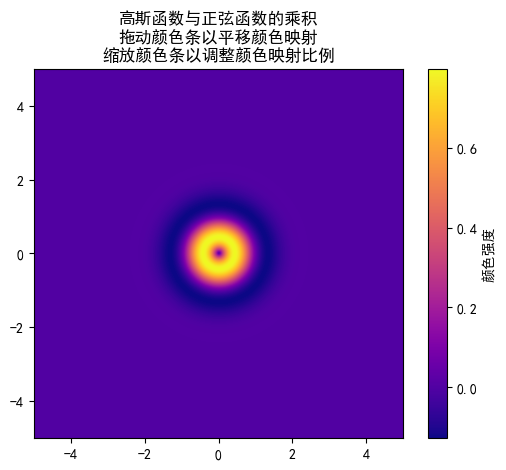

In [17]:
# 生成数据
x = np.linspace(-5, 5, 400)  # x轴范围
y = np.linspace(-5, 5, 400)  # y轴范围
X, Y = np.meshgrid(x, y)  # 创建网格
Z = np.exp(-X**2 - Y**2) * np.sin(3 * np.sqrt(X**2 + Y**2))  # 计算二维高斯函数与正弦函数的乘积

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 显示数据
im = ax.imshow(Z, extent=(-5, 5, -5, 5), origin='lower', cmap='plasma')

# 设置标题
ax.set_title('高斯函数与正弦函数的乘积\n'
             '拖动颜色条以平移颜色映射\n'
             '缩放颜色条以调整颜色映射比例')

# 添加颜色条
cbar = fig.colorbar(im, ax=ax, label='颜色强度')

plt.show()


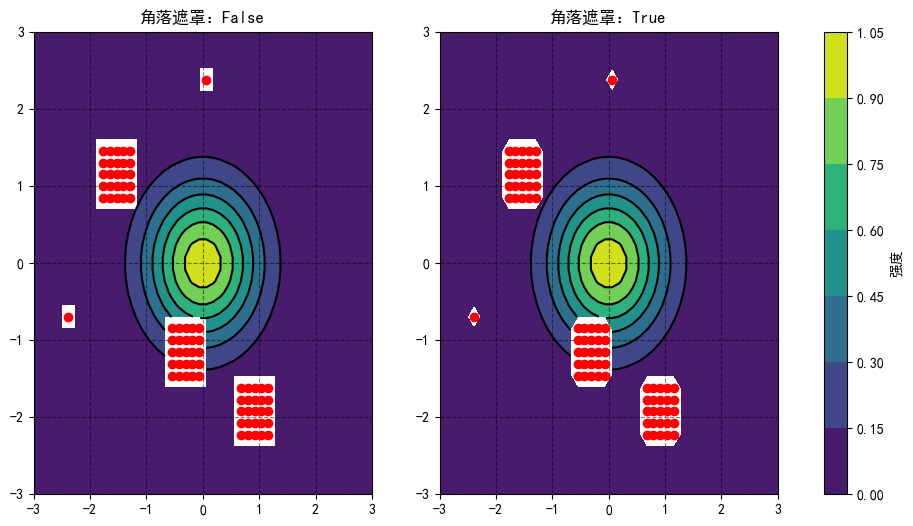

In [19]:
# 生成数据
x, y = np.meshgrid(np.linspace(-3, 3, 50), np.linspace(-3, 3, 40))
z = np.exp(-x**2 - y**2)  # 计算二维高斯函数

# 遮罩某些 z 值
mask = np.zeros_like(z, dtype=bool)
mask[10:15, 20:25] = True
mask[25:30, 10:15] = True
mask[5:10, 30:35] = True
mask[35, 25] = True
mask[15, 5] = True
z = np.ma.array(z, mask=mask)

corner_masks = [False, True]
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

for ax, corner_mask in zip(axs, corner_masks):
    # 填充等高线
    cs = ax.contourf(x, y, z, corner_mask=corner_mask, cmap='viridis')
    ax.contour(x, y, z, colors='k')  # 绘制等高线
    ax.set_title(f'角落遮罩：{corner_mask}')

    # 绘制网格
    ax.grid(c='k', ls='--', alpha=0.5)

    # 用红色圆圈标记遮罩的点
    ax.plot(np.ma.array(x, mask=~mask), np.ma.array(y, mask=~mask), 'ro')

# 添加颜色条
fig.colorbar(cs, ax=axs, orientation='vertical', label='强度')

plt.show()

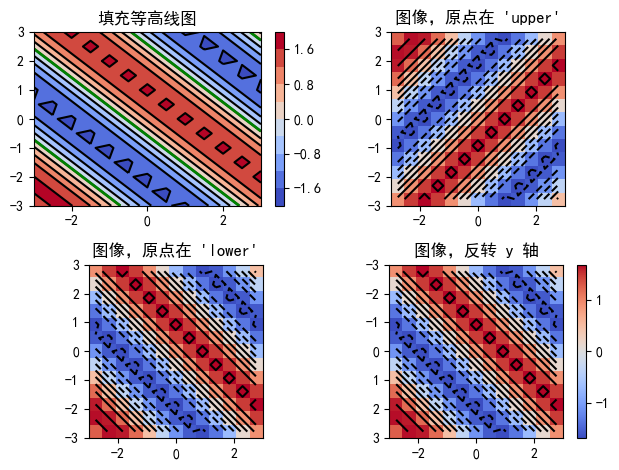

In [23]:
from matplotlib import cm

# 设置网格间距
delta = 0.5

# 设置数据范围
extent = (-3, 3, -3, 3)

# 创建网格数据
x = np.arange(-3.0, 3.001, delta)
y = np.arange(-3.0, 3.001, delta)
X, Y = np.meshgrid(x, y)
Z1 = np.sin(X) * np.cos(Y)  # 修改为 sin 和 cos 函数
Z2 = np.sin(X - 1) * np.cos(Y - 1)
Z = (Z1 - Z2) * 2

# 设置等高线级别
levels = np.arange(-2.0, 2.1, 0.4)

# 归一化颜色映射
norm = cm.colors.Normalize(vmax=abs(Z).max(), vmin=-abs(Z).max())
cmap = cm.coolwarm

# 创建子图
fig, _axs = plt.subplots(nrows=2, ncols=2)
fig.subplots_adjust(hspace=0.3)
axs = _axs.flatten()

# 绘制填充等高线
cset1 = axs[0].contourf(X, Y, Z, levels, norm=norm, cmap=cmap)
cset2 = axs[0].contour(X, Y, Z, cset1.levels, colors='k')
cset2.set_linestyle('solid')  # 使等高线为实线
cset3 = axs[0].contour(X, Y, Z, (0,), colors='g', linewidths=2)  # 绘制零值等高线
axs[0].set_title('填充等高线图')
fig.colorbar(cset1, ax=axs[0])  # 添加颜色条

# 显示图像并叠加等高线
axs[1].imshow(Z, extent=extent, cmap=cmap, norm=norm)
axs[1].contour(Z, levels, colors='k', origin='upper', extent=extent)
axs[1].set_title("图像，原点在 'upper'")

axs[2].imshow(Z, origin='lower', extent=extent, cmap=cmap, norm=norm)
axs[2].contour(Z, levels, colors='k', origin='lower', extent=extent)
axs[2].set_title("图像，原点在 'lower'")

# 使用最近邻插值
im = axs[3].imshow(Z, interpolation='nearest', extent=extent, cmap=cmap, norm=norm)
axs[3].contour(Z, levels, colors='k', origin='image', extent=extent)
ylim = axs[3].get_ylim()
axs[3].set_ylim(ylim[::-1])  # 反转 y 轴
axs[3].set_title("图像，反转 y 轴")
fig.colorbar(im, ax=axs[3])  # 添加颜色条

fig.tight_layout()
plt.show()


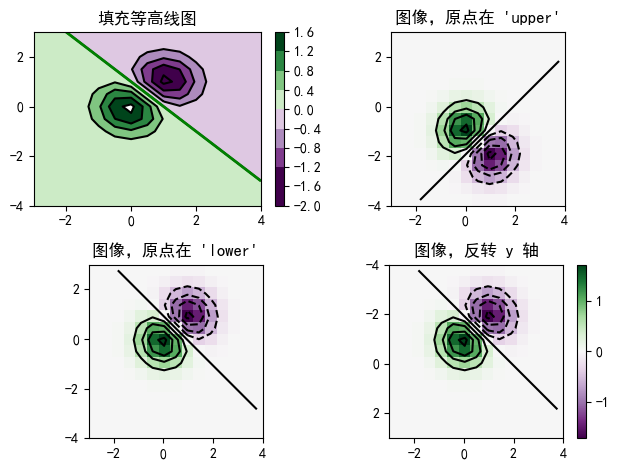

In [25]:
from matplotlib import cm

# 设置网格间距
delta = 0.5

# 定义坐标范围
extent = (-3, 4, -4, 3)

# 生成网格数据
x = np.arange(-3.0, 4.001, delta)
y = np.arange(-4.0, 3.001, delta)
X, Y = np.meshgrid(x, y)

# 计算数据
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
Z = (Z1 - Z2) * 2

# 设置等高线的级别
levels = np.arange(-2.0, 1.601, 0.4)

# 归一化数据范围
norm = cm.colors.Normalize(vmax=abs(Z).max(), vmin=-abs(Z).max())
cmap = cm.PRGn

# 创建子图
fig, axs = plt.subplots(nrows=2, ncols=2)
fig.subplots_adjust(hspace=0.3)

# 绘制填充等高线图
cset1 = axs[0, 0].contourf(X, Y, Z, levels, norm=norm, cmap=cmap.resampled(len(levels) - 1))
# 注意：色图的级别数量应比实际级别少1，避免离散化误差

cset2 = axs[0, 0].contour(X, Y, Z, cset1.levels, colors='k')
# 关闭虚线等高线，改为实线
cset2.set_linestyle('solid')

# 绘制零值等高线，使用绿色实线
cset3 = axs[0, 0].contour(X, Y, Z, (0,), colors='g', linewidths=2)
axs[0, 0].set_title('填充等高线图')
fig.colorbar(cset1, ax=axs[0, 0])  # 添加颜色条

# 图像显示：原点在上方
axs[0, 1].imshow(Z, extent=extent, cmap=cmap, norm=norm)
axs[0, 1].contour(Z, levels, colors='k', origin='upper', extent=extent)
axs[0, 1].set_title("图像，原点在 'upper'")

# 图像显示：原点在下方
axs[1, 0].imshow(Z, origin='lower', extent=extent, cmap=cmap, norm=norm)
axs[1, 0].contour(Z, levels, colors='k', origin='lower', extent=extent)
axs[1, 0].set_title("图像，原点在 'lower'")

# 使用最近邻插值显示图像
im = axs[1, 1].imshow(Z, interpolation='nearest', extent=extent, cmap=cmap, norm=norm)
axs[1, 1].contour(Z, levels, colors='k', origin='image', extent=extent)
ylim = axs[1, 1].get_ylim()
axs[1, 1].set_ylim(ylim[::-1])  # 反转 y 轴
axs[1, 1].set_title("图像，反转 y 轴")
fig.colorbar(im, ax=axs[1, 1])  # 添加颜色条

# 调整布局
fig.tight_layout()
plt.show()


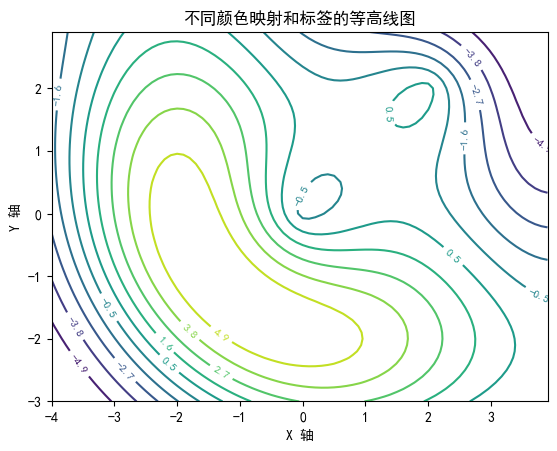

In [29]:
import matplotlib.cm as cm

# 设置网格间距
delta = 0.1

# 定义网格范围
x = np.arange(-4.0, 4.0, delta)
y = np.arange(-3.0, 3.0, delta)
X, Y = np.meshgrid(x, y)

# 计算数据
Z1 = np.sin(np.sqrt(X**2 + Y**2))
Z2 = np.sin(np.sqrt((X - 2)**2 + (Y - 2)**2))
Z = (Z1 - Z2) * 3

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 绘制等高线图，使用不同的颜色映射和级别
levels = np.linspace(-6, 6, 12)
CS = ax.contour(X, Y, Z, levels, cmap=cm.viridis)

# 为等高线添加标签
ax.clabel(CS, inline=True, fontsize=8, fmt='%1.1f')

# 设置标题和坐标轴标签
ax.set_title('不同颜色映射和标签的等高线图')
ax.set_xlabel('X 轴')
ax.set_ylabel('Y 轴')

plt.show()
